# Simple CNN using keras

## import libraries

In [103]:
import enum
import json
from numpy.random import shuffle
import tensorflow  as tf
import numpy as np
from tensorflow import keras
from tensorflow.keras import callbacks, layers, metrics, optimizers

## loading mnist

In [104]:
def print_data_info(x_train, y_train, x_test, y_test):
    for name, data in zip(['x_train','y_train','x_test','y_test'],
                          [x_train, y_train, x_test, y_test]):
        print(name, type(data), data.shape, data.dtype)

# Load a sample dataset (MNIST for simplicity)
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
print_data_info(x_train, y_train, x_test, y_test);

x_train <class 'numpy.ndarray'> (60000, 28, 28) uint8
y_train <class 'numpy.ndarray'> (60000,) uint8
x_test <class 'numpy.ndarray'> (10000, 28, 28) uint8
y_test <class 'numpy.ndarray'> (10000,) uint8


## reshaping and type conversion

In [105]:
# Normalize and reshape data
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = np.expand_dims(x_train, axis=-1) # Add channel dimension
x_test = np.expand_dims(x_test, axis=-1)

print_data_info(x_train, y_train, x_test, y_test);

x_train <class 'numpy.ndarray'> (60000, 28, 28, 1) float32
y_train <class 'numpy.ndarray'> (60000,) uint8
x_test <class 'numpy.ndarray'> (10000, 28, 28, 1) float32
y_test <class 'numpy.ndarray'> (10000,) uint8


## building sequential model

In [106]:
input_shape=(28, 28, 1)
model = keras.Sequential([
    layers.Input(shape=input_shape),
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D((2, 2)),

    # feed into FCNN
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax"), # 10 classes
])

## model summary

In [107]:
model.summary()

Model: "sequential_9"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 conv2d_18 (Conv2D)          (None, 26, 26, 32)        320       


 max_pooling2d_18 (MaxPoolin  (None, 13, 13, 32)       0         


...

 dense_23 (Dense)            (None, 10)                1290      


Total params: 225,034


Trainable params: 225,034


Non-trainable params: 0


_________________________________________________________________


## compile the model

In [108]:
model.compile(
    optimizer="adam", 
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"]
)

## train the model

In [109]:
model.fit(
    x_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(x_test, y_test),
    verbose=0
)

## evaluate the model

In [110]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)
!nvcc --version

Num GPUs Available: 0
2.12.0


nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2026 NVIDIA Corporation
Built on Mon_Mar_02_09:52:23_PM_PST_2026
Cuda compilation tools, release 13.2, V13.2.51
Build cuda_13.2.r13.2/compiler.37434383_0


In [111]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")
# Make predictions
predictions = model.predict(x_test[:5], verbose=0)
predicted_labels = np.argmax(predictions, axis=1)
print("Predicted labels:", predicted_labels)
print("Actual labels: ", y_test[:5])

Test accuracy: 0.9915
Predicted labels: [7 2 1 0 4]
Actual labels:  [7 2 1 0 4]


# Exercise

## Task 1: Data Understanding and Visualization

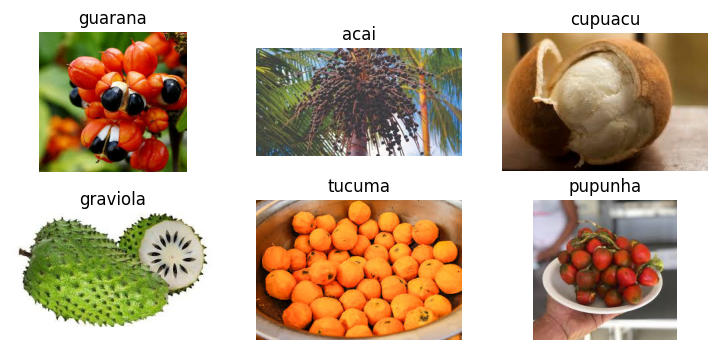

In [112]:
import os
import matplotlib.pyplot as plt
from PIL import Image

train_dir = "/home/rokshh/Documents/college/sem6/ai-deep-learning/week-5/dataset/train/"

# Get the list of class directories from the train folder.
dirs = os.listdir(train_dir)

select_img_paths = []
# Select one image randomly from each class.
for dir in dirs: 
    images =  os.listdir(os.path.join(train_dir, dir))
    random_idx = np.random.randint(0, len(images))

    img_path = os.path.join(train_dir, dir, images[random_idx])
    select_img_paths.append(img_path)

# Display the images in a grid format with two rows using matplotlib.
plt.figure(figsize=(9, 4))
for i, img_path in enumerate(select_img_paths):
    plt.subplot(2, 3, i + 1) 
    img = Image.open(img_path)
    plt.imshow(img)
    plt.axis("off")
    plt.title(img_path.split("/")[-2])

### check for corrupted images

In [113]:
def check_corrupted_images(dir):
    dirs = os.listdir(dir)
    images, corrupted_images = [], []
    for dir_path in dirs: 
        img_paths = os.listdir(os.path.join(dir, dir_path));
        for img in img_paths:
            img_path = os.path.join(dir, dir_path, img)
            try: 
                Image.open(img_path)
                images.append(img_path)
            except Exception as e:
                print(f"Error while opening image {img_path}", e)
                corrupted_images.append(img_path)
                os.remove(img_path)
                print(f"Removed corrupted image {img_path}", e)

    return images, corrupted_images;

images, corrupted_images = check_corrupted_images(train_dir)
if(len(corrupted_images) == 0):
    print(f"No corrupted images found")

No corrupted images found


## Task 2: Loading and Preprocessing Image Data in keras

In [114]:
import tensorflow as tf

# conts values
img_height, img_width = 128, 128
batch_size = 32
validation_split = 0.2

# Preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # normalize to [0, 1]

# creating training dataset
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels = "inferred",
    label_mode = "int",
    image_size = (img_height, img_width),
    interpolation = "nearest",
    batch_size = batch_size,
    shuffle =True,
    validation_split=validation_split,
    subset="training",
    seed=42
)

train_ds = train_ds.map(lambda x, y: (rescale(x), y))

val_dir = "/home/rokshh/Documents/college/sem6/ai-deep-learning/week-5/dataset/test/"

# creating validation dataset with normalization
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels = "inferred",
    label_mode = "int",
    image_size = (img_height, img_width),
    interpolation = "nearest",
    batch_size = batch_size,
    shuffle = False,
    validation_split=validation_split,
    subset="validation",
    seed=42
)

val_ds = val_ds.map(lambda x, y: (rescale(x), y))

Found 90 files belonging to 6 classes.


Using 72 files for training.
Found 90 files belonging to 6 classes.


Using 18 files for validation.


## Task3: implementing CNN

In [115]:
input_shape = (128, 128, 3)

model = tf.keras.Sequential([
    layers.Input(shape=input_shape),
    layers.Conv2D(32, (3, 3), 1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),
    layers.Conv2D(32, (3, 3), 1, padding="same", activation="relu"),
    layers.MaxPooling2D(pool_size=(2, 2), strides=2),

    # FCNN
    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dense(128, activation="relu"),
    layers.Dense(6, activation="softmax"), # 6 classes
])

model.summary()

Model: "sequential_10"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 conv2d_20 (Conv2D)          (None, 128, 128, 32)      896       


 max_pooling2d_20 (MaxPoolin  (None, 64, 64, 32)       0         


...

 dense_26 (Dense)            (None, 6)                 774       


Total params: 2,116,454


Trainable params: 2,116,454


Non-trainable params: 0


_________________________________________________________________


## Model Compilation

In [116]:
model.compile(
    optimizer="adam", 
    loss="sparse_categorical_crossentropy", 
    metrics=["accuracy"]
)

## Task 4: Train the model

### model training

In [117]:
import json

# make sure 
os.makedirs("./model_checkpoints", exist_ok=True)

callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="./model_checkpoints/model_at_epoch_{epoch}.keras"),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=4)
]

history = model.fit(
    train_ds,
    epochs=250,
    batch_size=16,
    validation_data=val_ds,
    callbacks=callbacks,
    verbose=0
)

print(history.history.keys())
print(json.dumps(history.history, indent=2))

2026-04-03 16:56:54.032035: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [72]
	 [[{{node Placeholder/_4}}]]
2026-04-03 16:56:54.032226: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [72]
	 [[{{node Placeholder/_0}}]]


2026-04-03 16:56:54.676138: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [18]
	 [[{{node Placeholder/_4}}]]
2026-04-03 16:56:54.676286: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [18]
	 [[{{node Placeholder/_4}}]]


dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])
{
  "loss": [
    2.20857310295105,
    1.7470612525939941,
    1.6469464302062988,
    1.5170204639434814,
    1.3670512437820435,
    1.2146178483963013,
    1.0621083974838257,
    0.7961055040359497,
    0.6465046405792236,
    0.7212350964546204,
    0.5683166980743408,
    0.4067433178424835,
    0.302998811006546
  ],
  "accuracy": [
    0.1388888955116272,
    0.2222222238779068,
    0.25,
    0.4444444477558136,
    0.5,
    0.5138888955116272,
    0.6944444179534912,
    0.75,
    0.7916666865348816,
    0.7638888955116272,
    0.7777777910232544,
    0.8888888955116272,
    0.9583333134651184
  ],
  "val_loss": [
    1.7911744117736816,
    1.3611538410186768,
    1.4717097282409668,
    1.3339873552322388,
    2.0133252143859863,
    1.2878491878509521,
    0.9842734932899475,
    0.8553159236907959,
    0.6145778298377991,
    1.2523725032806396,
    0.6899229884147644,
    0.6934878826141357,
    1.18775367736816

## Task 5: Model Evaluation

In [118]:
test_dir = "/home/rokshh/Documents/college/sem6/ai-deep-learning/week-5/dataset/test/"

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    labels = "inferred",
    label_mode = "int",
    image_size = (img_height, img_width),
    batch_size = batch_size,
    shuffle = False,
    seed=42
)

loss, accuracy = model.evaluate(
    test_ds,
    batch_size=batch_size,
    verbose=0
)

print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Found 30 files belonging to 6 classes.


Test Loss: 154.0257
Test Accuracy: 0.5000


2026-04-03 16:56:58.794930: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [30]
	 [[{{node Placeholder/_4}}]]
2026-04-03 16:56:58.795082: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [30]
	 [[{{node Placeholder/_4}}]]


## Task 6: Save and Load the Model

In [119]:
model.save('image_classifier_cnn.h5')
loaded_model = tf.keras.models.load_model('image_classifier_cnn.h5')

## Task 7: Predictions and Classification Report

In [123]:
# predict on test data
predictions = loaded_model.predict(test_ds, verbose=0)

# Convert predictions from probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)

first_batch = next(iter(val_ds.take(1)))
images, labels = first_batch

# Check the first prediction
print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image: {labels[0].numpy()}")

Predicted label for first image: 1
True label for first image: 4


2026-04-03 16:57:24.901605: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_0' with dtype string and shape [18]
	 [[{{node Placeholder/_0}}]]
2026-04-03 16:57:24.901828: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_4' with dtype int32 and shape [18]
	 [[{{node Placeholder/_4}}]]


### clasification report

In [124]:
from sklearn.metrics import classification_report

# class names are automatically inferred from folder names
class_names = test_ds.class_names  

true_labels = []
predicted_labels = []

for images, labels in test_ds:
    preds = loaded_model.predict(images, verbose=0)
    predicted_labels.extend(np.argmax(preds, axis=1))
    true_labels.extend(labels.numpy())

true_labels = np.array(true_labels)
predicted_labels = np.array(predicted_labels)

# pass class names here ↓
report = classification_report(true_labels, predicted_labels, target_names=class_names)
print(report)

              precision    recall  f1-score   support

           0       0.75      0.60      0.67         5
           1       0.25      0.40      0.31         5
           2       0.44      0.80      0.57         5
           3       0.50      0.60      0.55         5
           4       1.00      0.20      0.33         5
           5       1.00      0.40      0.57         5

    accuracy                           0.50        30
   macro avg       0.66      0.50      0.50        30
weighted avg       0.66      0.50      0.50        30



### visualization

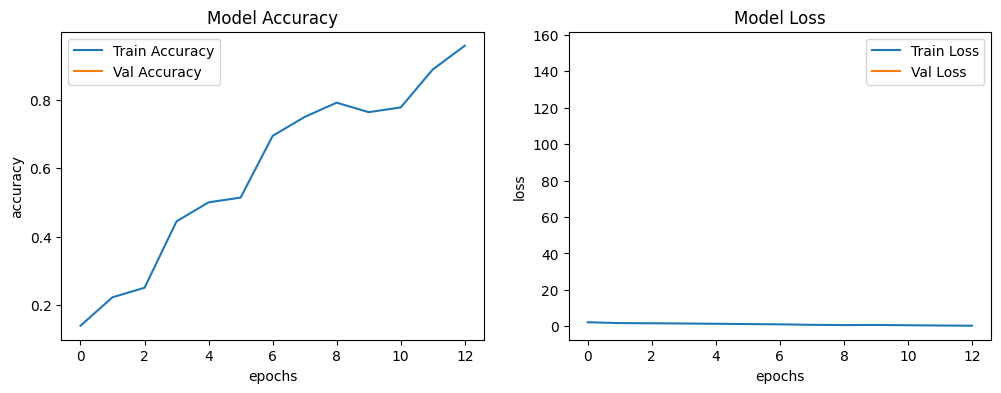

In [125]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Model Accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
